# Predicción de Ingresos Totales del Canal de Panamá
## Modelo: KNN Regressor (K-Nearest Neighbors)

## ¿Qué es KNN Regressor?

KNN Regressor es un algoritmo de aprendizaje **no paramétrico** y **basado en instancias**. A diferencia de modelos que aprenden una función explícita, KNN almacena todo el conjunto de entrenamiento y realiza predicciones al momento de la inferencia.

### Cómo funciona

1. Para cada punto nuevo, se calcula la **distancia** a todos los puntos del conjunto de entrenamiento.
2. Se seleccionan los **K vecinos más cercanos**.
3. La predicción es el **promedio** de los valores objetivo de esos K vecinos (en regresión).

### Métricas de distancia

- **Euclídea**: $d(x,y) = \sqrt{\sum_i (x_i - y_i)^2}$ — la más común.
- **Manhattan**: $d(x,y) = \sum_i |x_i - y_i|$ — más robusta ante outliers.

### Escalamiento de features

Dado que KNN calcula distancias, las features deben escalarse para que ninguna domine por su magnitud. **StandardScaler** transforma cada feature a media=0 y desviación estándar=1.

### Selección de K

| K pequeño | K grande |
|-----------|----------|
| Sobreajuste (overfitting) | Subajuste (underfitting) |
| Frontera de decisión irregular | Frontera demasiado suavizada |
| Sensible al ruido | Pierde patrones locales |

### Ventajas
- Simple de entender e implementar.
- Sin fase de entrenamiento (lazy learning).
- Se adapta a cualquier forma de frontera de decisión.

### Limitaciones
- Costoso computacionalmente en predicción con grandes volúmenes de datos.
- Sensible a features irrelevantes y a la escala.
- Requiere escalamiento obligatorio.
- Maldición de la dimensionalidad: con muchas features, la distancia pierde significado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


## 1. Carga y Preparación de Datos

In [2]:
df = pd.read_csv("A07607236202602121443442025_transporte_acp.csv", encoding='latin-1')

df = df.rename(columns={
    "Ingresos por Peaje Panamax": "Ingresos Panamax",
    "Ingresos por Peaje NeoPanamax": "Ingresos NeoPanamax",
    "Tonelada Netas Neopanamax": "Toneladas Netas NeoPanamax"
})

df["Ingresos Totales"] = df["Ingresos Panamax"] + df["Ingresos NeoPanamax"]
df["Total Transitos"] = (
    df["Transito de Naves Alto Calado Panamax"]
    + df["Transito de Naves Pequeño Calado Panamax"]
    + df["Transito de Naves NeoPanamax"]
)
df["Total Toneladas"] = df["Toneladas Netas Panamax"] + df["Toneladas Netas NeoPanamax"]
df["Total Volumen"] = df["Volumen de Carga Panamax"] + df["Volumen de Carga NeoPanamax"]

meses = {
    "Enero": 1, "Febrero": 2, "Marzo": 3, "Abril": 4,
    "Mayo": 5, "Junio": 6, "Julio": 7, "Agosto": 8,
    "Septiembre": 9, "Octubre": 10, "Noviembre": 11, "Diciembre": 12
}
df["Num_Mes"] = df["Mes"].map(meses)
df["Mes_Indice"] = range(len(df))

print(f"Dimensiones del dataset: {df.shape}")
df.head()

Dimensiones del dataset: (72, 17)


,Año,Mes,Transito de Naves Alto Calado Panamax,Transito de Naves Pequeño Calado Panamax,Ingresos Panamax,Toneladas Netas Panamax,Volumen de Carga Panamax,Transito de Naves NeoPanamax,Ingresos NeoPanamax,Toneladas Netas NeoPanamax,Volumen de Carga NeoPanamax,Ingresos Totales,Total Transitos,Total Toneladas,Total Volumen,Num_Mes,Mes_Indice
0,2020,Enero,826,149,110198056,21167387,13324583,308,135551279,23811798,9311252,245749335,1283,44979185,22635835,1,0
1,2020,Febrero,753,206,100158695,19293825,13054336,268,112186169,19811487,8662008,212344864,1227,39105312,21716344,2,1
2,2020,Marzo,825,124,110757041,21512145,15397768,261,105134233,19232310,7836721,215891274,1210,40744455,23234489,3,2
3,2020,Abril,698,53,96144271,17615626,13232901,271,121704852,19898460,9636220,217849123,1022,37514086,22869121,4,3
4,2020,Mayo,640,43,85960793,15530225,12631808,254,115570390,18800359,7521629,201531183,937,34330584,20153437,5,4


## 2. Selección de Features y División de Datos

> **Nota importante para KNN:** A diferencia de modelos basados en árboles, KNN es **sensible a la escala** de las features. Es obligatorio aplicar **StandardScaler** antes de entrenar.

In [3]:
features = [
    "Transito de Naves Alto Calado Panamax",
    "Transito de Naves Pequeño Calado Panamax",
    "Toneladas Netas Panamax",
    "Volumen de Carga Panamax",
    "Transito de Naves NeoPanamax",
    "Toneladas Netas NeoPanamax",
    "Volumen de Carga NeoPanamax",
    "Total Transitos",
    "Total Toneladas",
    "Total Volumen",
    "Num_Mes",
    "Mes_Indice"
]

target = "Ingresos Totales"

train = df[df["Año"] < 2025]
val = df[df["Año"] == 2025]

X_train = train[features].copy()
y_train = train[target].copy()
X_val = val[features].copy()
y_val = val[target].copy()

# Scale features (critical for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print(f"Datos de entrenamiento: {X_train.shape[0]} registros (2020-2024)")
print(f"Datos de validación:    {X_val.shape[0]} registros (2025)")
print(f"\nFeatures escaladas con StandardScaler (media=0, std=1)")

Datos de entrenamiento: 60 registros (2020-2024)
Datos de validación:    12 registros (2025)

Features escaladas con StandardScaler (media=0, std=1)


## 3. Búsqueda del K Óptimo

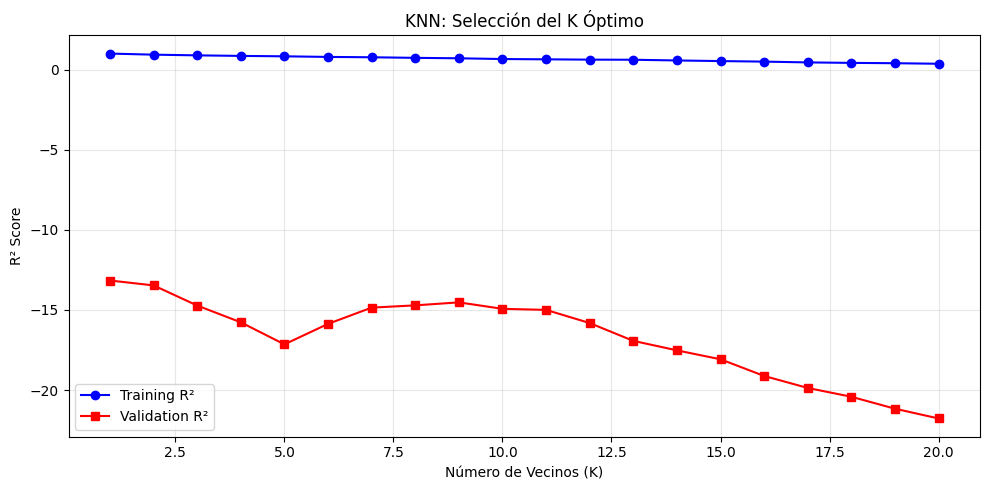

K óptimo (mayor R² en validación): 1


In [4]:
k_values = range(1, 21)
train_scores = []
val_scores = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    val_scores.append(knn.score(X_val_scaled, y_val))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_values), train_scores, 'b-o', label='Training R²')
ax.plot(list(k_values), val_scores, 'r-s', label='Validation R²')
ax.set_xlabel('Número de Vecinos (K)')
ax.set_ylabel('R² Score')
ax.set_title('KNN: Selección del K Óptimo')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = list(k_values)[np.argmax(val_scores)]
print(f"K óptimo (mayor R² en validación): {best_k}")

## 4. Entrenamiento del Modelo

In [5]:
model = KNeighborsRegressor(n_neighbors=best_k)
model.fit(X_train_scaled, y_train)
y_pred_val = model.predict(X_val_scaled)

print(f"Modelo KNN entrenado con K={best_k}")

Modelo KNN entrenado con K=1


## 5. Evaluación del Modelo

In [6]:
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
mae = mean_absolute_error(y_val, y_pred_val)
r2 = r2_score(y_val, y_pred_val)

print(f"=== Métricas de Evaluación (Validación 2025) ===")
print(f"RMSE:  ${rmse:,.0f}")
print(f"MAE:   ${mae:,.0f}")
print(f"R²:    {r2:.4f}")

=== Métricas de Evaluación (Validación 2025) ===
RMSE:  $51,677,217
MAE:   $44,769,477
R²:    -13.1620


## 6. Visualización: Reales vs Predichos (2025)

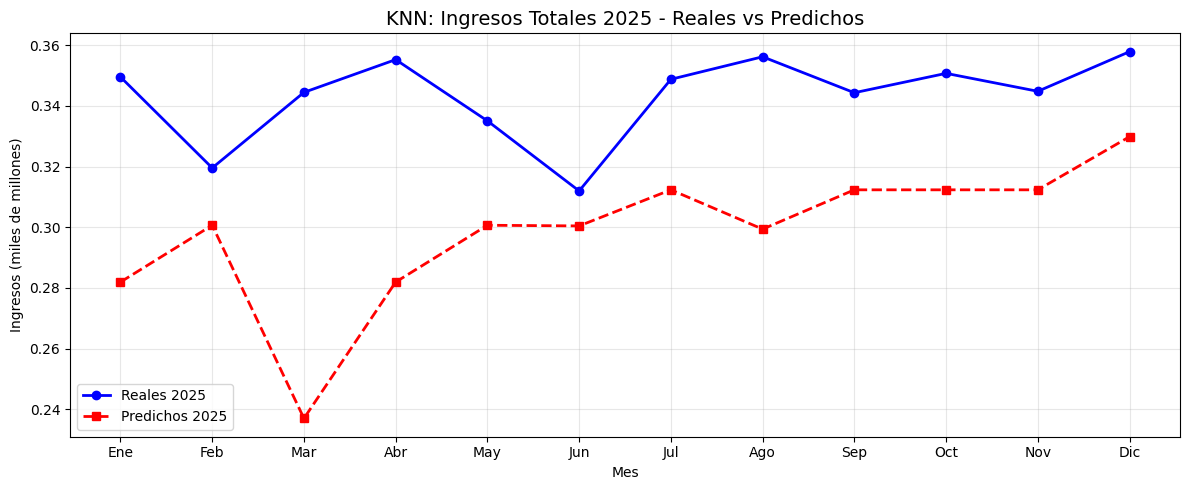

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
x_axis = range(1, 13)
meses_labels = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

ax.plot(x_axis, y_val.values / 1e9, 'b-o', label='Reales 2025', linewidth=2)
ax.plot(x_axis, y_pred_val / 1e9, 'r--s', label='Predichos 2025', linewidth=2)
ax.set_xticks(x_axis)
ax.set_xticklabels(meses_labels)
ax.set_title('KNN: Ingresos Totales 2025 - Reales vs Predichos', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos (miles de millones)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Predicción de Ingresos Totales 2026

In [8]:
meses_nombre = ["Enero", "Febrero", "Marzo", "Abril", "Mayo", "Junio",
                "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]

predict_2026 = pd.DataFrame()
for i, mes in enumerate(meses_nombre):
    row = {
        "Año": 2026,
        "Mes": mes,
        "Num_Mes": i + 1,
        "Mes_Indice": 72 + i,
    }
    month_avg = df[df["Mes"] == mes][features[:-2]].mean()
    for feat in features[:-2]:
        row[feat] = month_avg[feat]
    predict_2026 = pd.concat([predict_2026, pd.DataFrame([row])], ignore_index=True)

X_2026 = predict_2026[features]
X_2026_scaled = scaler.transform(X_2026)
predicciones_2026 = model.predict(X_2026_scaled)
predict_2026["Ingresos Totales Predichos"] = predicciones_2026

print("=== Predicción de Ingresos Totales 2026 ===")
for _, row in predict_2026.iterrows():
    print(f"{row['Mes']:12s}: ${row['Ingresos Totales Predichos']:>18,.0f}")

total_2026 = predict_2026["Ingresos Totales Predichos"].sum()
print(f"\n{'Total 2026':12s}: ${total_2026:>18,.0f}")

=== Predicción de Ingresos Totales 2026 ===
Enero       : $       281,942,672
Febrero     : $       266,020,322
Marzo       : $       266,020,322
Abril       : $       281,942,672
Mayo        : $       313,121,268
Junio       : $       300,439,532
Julio       : $       313,121,268
Agosto      : $       313,121,268
Septiembre  : $       306,268,484
Octubre     : $       312,335,318
Noviembre   : $       312,335,318
Diciembre   : $       312,335,318

Total 2026  : $     3,579,003,762


## 8. Visualización de Tendencia Histórica y Predicción 2026

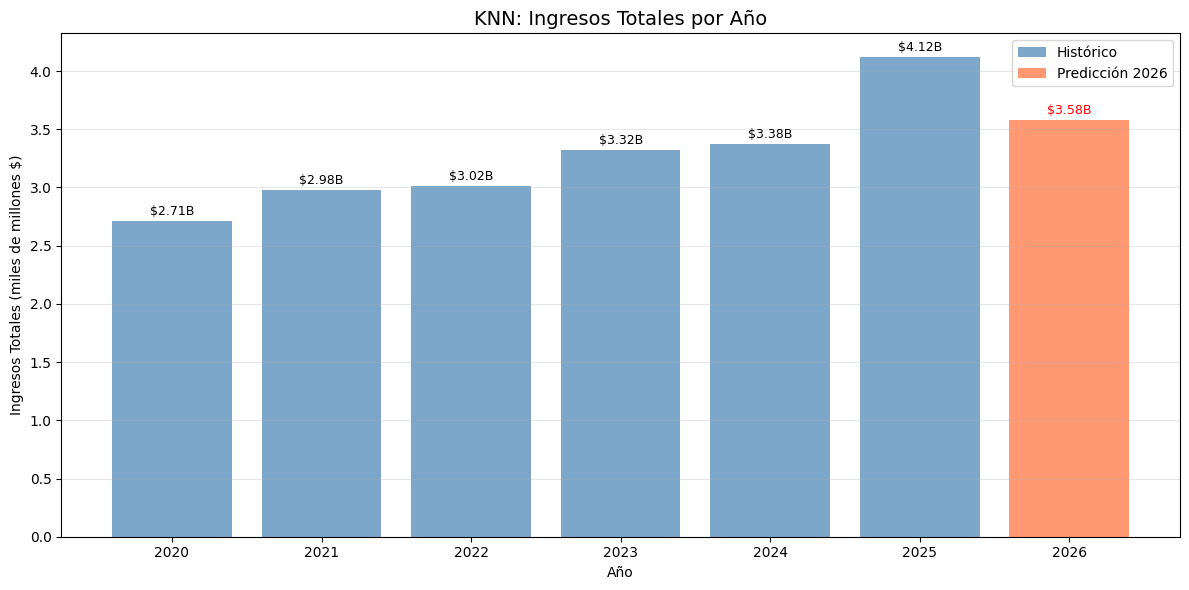

In [9]:
ingresos_anuales = df.groupby("Año")["Ingresos Totales"].sum()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(ingresos_anuales.index.astype(str), ingresos_anuales.values / 1e9, 
       color='steelblue', alpha=0.7, label='Histórico')
ax.bar("2026", total_2026 / 1e9, color='coral', alpha=0.8, label='Predicción 2026')

for i, (year, val) in enumerate(ingresos_anuales.items()):
    ax.text(i, val / 1e9 + 0.05, f'${val/1e9:.2f}B', ha='center', fontsize=9)
ax.text(len(ingresos_anuales), total_2026 / 1e9 + 0.05, f'${total_2026/1e9:.2f}B', 
        ha='center', fontsize=9, color='red')

ax.set_title('KNN: Ingresos Totales por Año', fontsize=14)
ax.set_xlabel('Año')
ax.set_ylabel('Ingresos Totales (miles de millones $)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
predict_2026[["Año", "Mes", "Ingresos Totales Predichos"]].to_csv("prediccion_2026.csv", index=False)
print("Predicciones exportadas a prediccion_2026.csv")

Predicciones exportadas a prediccion_2026.csv


## Conclusiones
- KNN es un modelo no paramétrico que basa sus predicciones en la similitud con puntos cercanos en el espacio de features.
- La estandarización de features es crítica ya que KNN depende de distancias euclidianas.
- El K óptimo se selecciona mediante validación, balanceando sobreajuste (K pequeño) y suavizado excesivo (K grande).
- Ventaja: simple de entender e implementar, se adapta a patrones no lineales.
- Limitación: lento en predicción con grandes volúmenes, sensible a features irrelevantes y a la escala.